# Graphs

A Graph is a ordered pair of `V` vertices and a set of `E` edges
- G = (V,E)

Graphs can be directed, undirected, or both (in some cases)

*direct* = (X,Y) ordered paired

*undirect* = unordred pair bi-directional

*path* = a sequence of edges which connect a sequence of vertices. 
- can be direct or undirected or both

*Simple path* = A path that does not repeat vertices`

Weighted Graphs: Edges can have "weights" or costs associated with them


## Graph Representations

How we store graphs in memory affects both the space (memory) and time (speed) complexity of our operations

Edge List & Vertex List: 
Stores a list of all vertices and a separate list of all edges. 
To find adjacent nodes, the time complexity is O(|E|) because you must search the list of edges. The total space complexity is O(|V|+|E|).

**Adjacency Matrix**: 
A 2-dimensional $n \times n$ array (where $n$ is the number of vertices). If there is an edge between vertex $i$ and vertex $j$, the matrix cell $A_{ij} = 1$; otherwise, it is $0$.
- Finding if two nodes are connected is incredibly fast at $O(1)$ time.
- Finding all adjacent nodes takes $O(|V|)$ time.
- Adjacency matrices `consume a lot of space and are only efficient for "dense" graphs (graphs with many edges)`. For undirected graphs, this matrix is always symmetrical.
- a 2D array, which means it allocates space for every possible connection, resulting in a space complexity of $O(v^{2})$

**Adjacency List**: 
Often implemented using a linked list or binary search tree. Each vertex stores a list of references to its immediate neighbors.

## Graph Traversals

Traversals refer to the process of systematically visiting every vertex and edge in a graph. 

We keep track of nodes we have already "visited" so we don't end up in an infinite loop.

### Depth-First Search (DFS): 

Explores as far down a single branch as possible before backtracking. 

DFS uses a *Stack* data structure (Last-In-First-Out) to keep track of the vertices to visit next.

Steps:
1. Pop the top node off the stack
2. if it is Unvisited, mark it as visited and add it to the Traversal Order
3. Look at its unvisited neighbors and Push them onto the Stack in reverse alphabetical order (so the earliest letter sits at the very top of the stack).



### Breadth-First Search (BFS):

Explores the graph level by level, visiting all immediate neighbors of a vertex before moving deeper. 

BFS uses a *Queue* data structure (First-In-First-Out)

BFS relies on a Queue (First-In, First-Out) to track which nodes to process next, and a Visited Set to ensure we don't process the same node twice.

So as soon as we pop from queue, we check its neighors and add it to the queue

manual trace:
1. Pop: Remove the node at the very front of the Queue.
2. Check: Look at that node's neighbors in your sorted Adjacency List.
3. Filter: Ignore any neighbors that are already in your Sequence (or currently in your Queue).
4. Push: Add the remaining unvisited neighbors to the back of the Queue.
5. Record: Immediately add those newly queued neighbors to your Sequence so you don't accidentally process them again later.

### DFS vs BFS

The Core Data Structure: Instead of `Stack<Integer>`, we use `Queue<Integer> queue = new LinkedList<>();`. A Queue is First-In, First-Out (FIFO). When you add Node A's neighbors (B, C, D) to the queue, B is at the front of the line, forcing the algorithm to check the immediate neighbors first before going deeper.

Iteration Order: In DFS, you used `.descendingIterator()` so that the first alphabetical letter sat at the top of the stack. In BFS, we just use a standard `.iterator().` Because it's a Queue, the first one you put in (B) naturally goes to the front of the line.

When Nodes are Marked Visited: In BFS, it is standard practice to mark a node as visited immediately before you put it into the Queue (`visited[neighbor] = true;`). This prevents a situation where multiple nodes try to add the exact same neighbor to the back of the queue before it gets processed.

## Practice Problems

### Implement Graph using an Adjacency Matrix Array 

> Implement the graph with eight different nodes as shown below using the adjacency matrix array

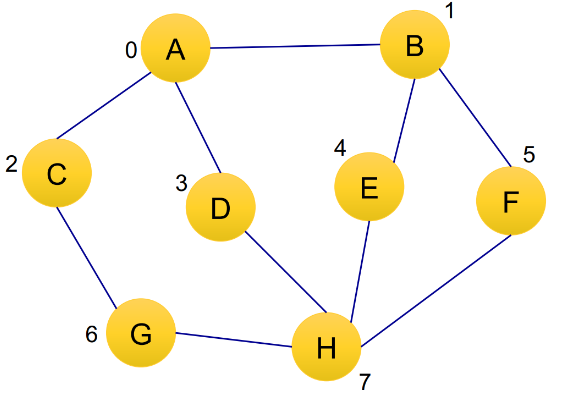

In [18]:
// AdjanceyMatrix
public class GraphAdjacencyMatrix {
    private int[][] matrix;
    private int numNodes;
    private char[] nodeNames = {'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'};
    
    // Constructor to initialize the matrix
    public GraphAdjacencyMatrix(int numNodes) {
        this.numNodes = numNodes;
        matrix = new int[numNodes][numNodes];
    }
    
    // Method to add an undirected edge between two nodes
    public void addEdge(int source, int destination) {
        matrix[source][destination] = 1;
        matrix[destination][source] = 1; // Because the graph is undirected
    }   
    
    // Method to display the matrix
    public void printMatrix() {
        System.out.println("Adjacency Matrix:\n");
        System.out.print(" ");
        // Print column headers
        for (char nodeName : nodeNames) {
            System.out.print(nodeName + " ");
        }
    
        System.out.println();
        
        // Print rows
        for (int i = 0; i < numNodes; i++) {
            System.out.print(nodeNames[i] + " ");
            for (int j = 0; j < numNodes; j++) {
                System.out.print(matrix[i][j] + " ");
            }
            System.out.println();
        }
    }
    
    public static void main(String[] args) {
        GraphAdjacencyMatrix graph = new GraphAdjacencyMatrix(8);
        // Node 0 (A) connects to B(1), C(2), D(3)
        graph.addEdge(0, 1);
        graph.addEdge(0, 2);
        graph.addEdge(0, 3);
        // Node 1 (B) connects to A(0), E(4), F(5)
        // Note: Edge to A(0) is already added above, so we skip it to avoid
        graph.addEdge(1, 4);
        graph.addEdge(1, 5);
        // Node 2 (C) connects to A(0), G(6)
        graph.addEdge(2, 6);
        // Node 3 (D) connects to A(0), H(7)
        graph.addEdge(3, 7);
        // Node 4 (E) connects to B(1), H(7)
        graph.addEdge(4, 7);
        // Node 5 (F) connects to B(1), H(7)
        graph.addEdge(5, 7);
        // Node 6 (G) connects to C(2), H(7)
        graph.addEdge(6, 7);
        // Node 7 (H) connections are already covered by the edges added above
        // Output the final matrix
        graph.printMatrix();
    }
}

GraphAdjacencyMatrix.main(null);

Adjacency Matrix:

 A B C D E F G H 
A 0 1 1 1 0 0 0 0 
B 1 0 0 0 1 1 0 0 
C 1 0 0 0 0 0 1 0 
D 1 0 0 0 0 0 0 1 
E 0 1 0 0 0 0 0 1 
F 0 1 0 0 0 0 0 1 
G 0 0 1 0 0 0 0 1 
H 0 0 0 1 1 1 1 0 


#### Adjacency Matrix Array: Total number of neighbors for each vertex in the Graph

The very first thing you should do when looking at an adjacency matrix is check for symmetry
- Because every connection is perfectly mirrored, this matrix is symmetrical. This tells us we are dealing with an `undirected` graph.

Thus for an `undirected` graph, to count the total number of neightbors is to count the number of 1s in that vertix row

- 20 nieghbors
- `20/2= 10` edges

### Implement Graph using an Adjacency Linked list

> Implement of the graph with eight nodes as shown below using the adjacency linked list.

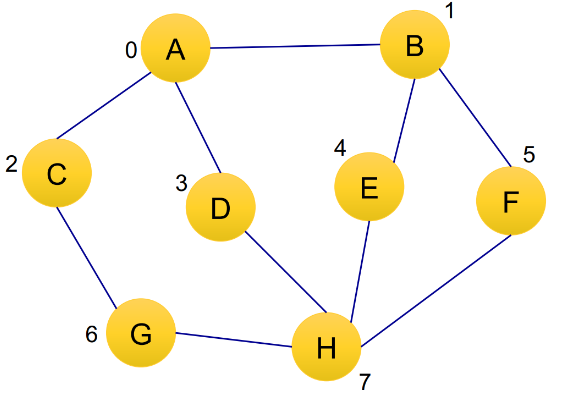

In [19]:
import java.util.LinkedList;
public class GraphAdjacencyList {
    private int numNodes;
    // Array of Linked Lists to store edges
    private LinkedList<Integer>[] adjList;
    private char[] nodeNames = {'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'};
    
    // Constructor to initialize the adjacency list
    @SuppressWarnings("unchecked")
    public GraphAdjacencyList(int numNodes) {
        this.numNodes = numNodes;
        adjList = new LinkedList[numNodes];
    
        // Initialize an empty linked list for each node
        for (int i = 0; i < numNodes; i++) {
            adjList[i] = new LinkedList<>();
        }
    }

    // Method to add an undirected edge between two nodes
    public void addEdge(int source, int destination) {
        // Add destination to the source's list
        adjList[source].add(destination);
        // Add source to the destination's list (because the graph is undirected)
        adjList[destination].add(source);
    }

    // Method to display the adjacency list
    public void printGraph() {
        System.out.println("Adjacency Linked List:\n");
        for (int i = 0; i < numNodes; i++) {
            System.out.print("Node " + nodeNames[i] + " (" + i + ") -> ");
            if (adjList[i].isEmpty()) {
                System.out.print("None");
            } else {
            for (Integer neighbor : adjList[i]) {
                System.out.print(nodeNames[neighbor] + "(" + neighbor + ") ");
            }
            }
                System.out.println();
        }
    }

    public static void main(String[] args) {
    GraphAdjacencyList graph = new GraphAdjacencyList(8);
    
    // Add edges based on the provided image
    // Node 0 (A) connects to B(1), C(2), D(3)
    graph.addEdge(0, 1);
    graph.addEdge(0, 2);
    graph.addEdge(0, 3);
    // Node 1 (B) connects to E(4), F(5)
    // (Connection to A is already handled automatically by addEdge)
    graph.addEdge(1, 4);
    graph.addEdge(1, 5);
    // Node 2 (C) connects to G(6)
    graph.addEdge(2, 6);
    // Node 3 (D) connects to H(7)
    graph.addEdge(3, 7);
    // Node 4 (E) connects to H(7)
    graph.addEdge(4, 7);
    // Node 5 (F) connects to H(7)
    graph.addEdge(5, 7);
    // Node 6 (G) connects to H(7)
    graph.addEdge(6, 7);
    // Node 7 (H) connections are already covered by the edges added above
    // Output the final adjacency list
    graph.printGraph();
    
    }

}


GraphAdjacencyList.main(null);

Adjacency Linked List:

Node A (0) -> B(1) C(2) D(3) 
Node B (1) -> A(0) E(4) F(5) 
Node C (2) -> A(0) G(6) 
Node D (3) -> A(0) H(7) 
Node E (4) -> B(1) H(7) 
Node F (5) -> B(1) H(7) 
Node G (6) -> C(2) H(7) 
Node H (7) -> D(3) E(4) F(5) G(6) 


#### Adjacency Linked List: Find the total number of neighbors for each vertex in the graph.

To find the number of neighbors, you are counting how many items are in the list for that specific vertex. In graph theory, this is called the Degree of the vertex.

Count the total number of edges

- 10

### Implement DFS

Implement the Depth-First-Search method in Java for the graph as shown below:

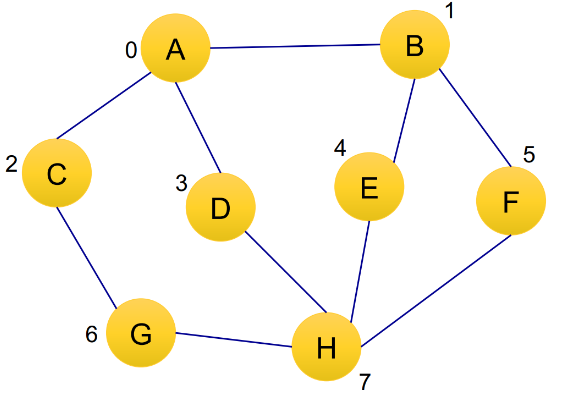

In [20]:

import java.util.*;

public class DFSGraph{ 
    private int numVertices; 
    private LinkedList<Integer>[] adjList; // Adjacency list representation

    // Constructor to initialize the graph
    @SuppressWarnings("unchecked")
    public DFSGraph(int vertices) {
        this.numVertices = vertices;
        adjList = new LinkedList[vertices];
        for (int i = 0; i < vertices; i++) {
            adjList[i] = new LinkedList<>();
        }
    }
    // Method to add an undirected edge
    public void addEdge(int source, int destination) {
        adjList[source].add(destination);
        adjList[destination].add(source); 
    }

    // Depth-First Search using a Stack
    public void dfsIterative(int startVertex) {
        // Track visited nodes to avoid infinite loops
        boolean[] visited = new boolean[numVertices];
        Stack<Integer> stack = new Stack<>();

        // Push the starting vertex onto the stack
        stack.push(startVertex);

        System.out.print("DFS Traversal Order: ");

        while (!stack.isEmpty()) {
            // Pop the top vertex from the stack
            int current = stack.pop();

            // If it hasn't been visited, process it
            if (!visited[current]) {
                System.out.print((char)('A' + current) + " "); 
                visited[current] = true;
            }

            // Get all adjacent vertices of the popped vertex
            // We iterate in reverse so the leftmost branch (alphabetically) is pushed last and popped first
            Iterator<Integer> it = adjList[current].descendingIterator();
            while (it.hasNext()) {
                int neighbor = it.next();
                if (!visited[neighbor]) {
                    stack.push(neighbor);
                }
            }
        }
        System.out.println();
    }
    
    public static void main(String[] args){
        // Create a graph with 8 vertices 
        // (A=0, B=1, C=2, D=3, E=4, F=5, G=6, H=7)
        DFSGraph graph = new DFSGraph(8);

        // Add edges based on the specific graph in your notes
        graph.addEdge(0, 1); // A - B
        graph.addEdge(0, 2); // A - C
        graph.addEdge(0, 3); // A - D
        graph.addEdge(1, 4); // B - E
        graph.addEdge(1, 5); // B - F
        graph.addEdge(2, 6); // C - G
        graph.addEdge(3, 7); // D - H
        graph.addEdge(4, 7); // E - H
        graph.addEdge(5, 7); // F - H
        graph.addEdge(6, 7); // G - H

        // Start the DFS traversal from Node A (index 0)
        graph.dfsIterative(0);
    }

}

DFSGraph.main(null);

DFS Traversal Order: A B E H D F G C 


#### Traversal sequence via DFS

> Print the traversal sequence using Depth-First Search (DFS) for the graph below:

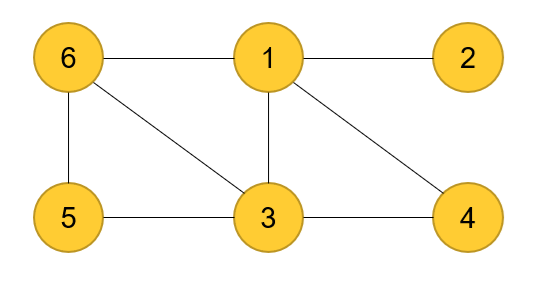


Steps:
1. Create Adjanency List sorted Numerically
2. track the Current Node, the Visited Sequence (our final answer), and the Stack (the path we took to get there, which we use to backtrack)

Adjaneency List:
1. [6,3,4,2]
2. [1]
3. [6,5,4,1]
4. [1,3]
5. [6,3]
6. [1,5,3]

Step 1:
- Sequence [1]
- Stack [1]

Step 2: Node 1's neighbors are 2, 3, 4, 6. Go to the smallest unvisited (2)
- Sequence [1,2]
- Stack [1,2]

Step 3: Node 2 only has 1 neighbor which is in the visited list, thus a dead-end. So we backtrack to 1
- Sequence [1,2]
- Stack [1]

Step 4: back at 1, its next unvisited neighbor is 3. Move to 3
- Sequence [1,2,3]
- Stack [1,3]

Step 5: Node 3's neighbors are [1,4,5,6], the smallest unvisited one if 4. Go to 4
- Sequence [1,2,3,4]
- Stack [1,3,4]

Step 6: Node 4's neighbors are [1,3], 1 and 3 were alread visited. So we go back to 3.
- Sequence [1,2,3,4]
- Stack [1,3]

Step 7: Node 3's next unvisited neighbor is 5, go to 5
- Sequence [1,2,3,4,5]
- stack [1,3,5]

Step 8: At Node 5, the 3 was already visited earlier but 6 wasn't, so add that to the stack and sequence and go there
- Sequence [1,2,3,4,5,6]
- stack [1,3,5,6]

Step 9: At node 6, there is [1,5,3], all of them were already visited. So we pop 6 from the stack and go back to 5
- Sequence [1,2,3,4,5,6]
- stack [1,3,5]

Step 10: At node 5, there is [6,3], all were visited. So we pop 5 and go back to 3
- Sequence [1,2,3,4,5,6]
- stack [1,3]

Step 11: At node 3, there is [1,4,5,6], all were visited. So we pop 3 and go back to 1
- Sequence [1,2,3,4,5,6]
- stack [1]

Step 12: At Node 1, there is [6,3,4,2]. Those were all visited, so we pop 1. 
- Sequence [1,2,3,4,5,6]
- stack []

Step 13: Since the stack is now null, we are done

### Implement BFS

Implement the Breadth-First-Search method in Java for the graph as shown below:

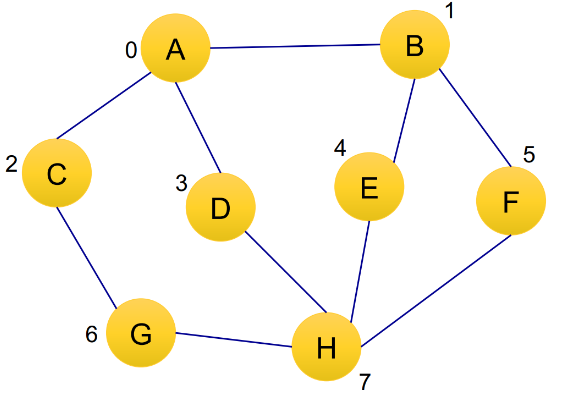

In [21]:
import java.util.*;

public class BFSGraph {
    private int numVertices; 
    private LinkedList<Integer>[] adjList; // Adjacency list representation (The Map)

    // Constructor to initialize the graph
    @SuppressWarnings("unchecked")
    public BFSGraph(int vertices) {
        this.numVertices = vertices;
        adjList = new LinkedList[vertices];
        for (int i = 0; i < vertices; i++) {
            adjList[i] = new LinkedList<>();
        }
    }

    // Method to add an undirected edge
    public void addEdge(int source, int destination) {
        adjList[source].add(destination);
        adjList[destination].add(source); 
    }

    // Breadth-First Search using a Queue
    public void bfsIterative(int startVertex) {
        // Track visited nodes to avoid infinite loops
        boolean[] visited = new boolean[numVertices];
        
        // Use a Queue instead of a Stack for BFS
        // In Java, LinkedList implements the Queue interface
        Queue<Integer> queue = new LinkedList<>();

        // Mark the starting vertex as visited and enqueue it
        visited[startVertex] = true;
        queue.add(startVertex);

        System.out.print("BFS Traversal Order: ");

        while (!queue.isEmpty()) {
            // Dequeue the front vertex and print it
            int current = queue.poll();
            System.out.print((char)('A' + current) + " "); 

            // Get all adjacent vertices of the dequeued vertex
            // We iterate normally (not in reverse) for standard alphabetical BFS
            Iterator<Integer> it = adjList[current].iterator();
            while (it.hasNext()) {
                int neighbor = it.next();
                
                // If the neighbor hasn't been visited, mark it and enqueue it
                if (!visited[neighbor]) {
                    visited[neighbor] = true; 
                    queue.add(neighbor);
                }
            }
        }
        System.out.println();
    }

    public static void main(String[] args) {
        // Create a graph with 8 vertices (A=0, B=1, C=2, D=3, E=4, F=5, G=6, H=7)
        BFSGraph graph = new BFSGraph(8);

        // Add edges based on the specific graph in your notes
        graph.addEdge(0, 1); // A - B
        graph.addEdge(0, 2); // A - C
        graph.addEdge(0, 3); // A - D
        graph.addEdge(1, 4); // B - E
        graph.addEdge(1, 5); // B - F
        graph.addEdge(2, 6); // C - G
        graph.addEdge(3, 7); // D - H
        graph.addEdge(4, 7); // E - H
        graph.addEdge(5, 7); // F - H
        graph.addEdge(6, 7); // G - H

        // Start the BFS traversal from Node A (index 0)
        graph.bfsIterative(0);
    }
}

BFSGraph.main(null);

BFS Traversal Order: A B C D E F G H 


#### Traversal sequence via BFS

> Print the traversal sequence using Breadth-First-Search( BFS) method.  

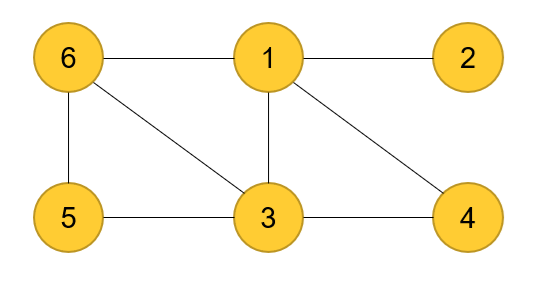

Steps:
1. Identify Adjancency List

Adjaneency List:
1. [6,3,4,2]
2. [1]
3. [6,5,4,1]
4. [1,3]
5. [6,3]
6. [1,5,3]

Step 0: inital state
- Visted: [1]
- Sequence: [1]
- Queue: [1]

Step 1: Pop 1 then add it's neighbors to the queue if it's not in the Unvisited boolean array, [2,3,4,6]
- Unvisited [2,3,4,6]
- Sequence [1,2]
- Queue [2,3,4,6]

Step 2: Pop 2 from queue, then check for unvisited neighbors  [1]. That has been visited. 
- Unvisited [3,4,6]
- Sequence [1,2,3]
- Queue [3,4,6]

Step 3: Pop 3, it has 1 unvisited node which is 5. Add that to the queue
- UnVisited [4,6]
- Sequence [1,2,3,4]
- Queue [4,6,5]

Step 4:
- Unvisited [6]
- Sequence [1,2,3,4,6]
- Queue [6,5]

Step 5:
- visited [1,2,3,4,6]
- Sequence [1,2,3,4,6]
- Queue [5]

Step 6: Done
- visited [1,2,3,4,6,5]
- Sequence [1,2,3,4,5]
- Queue []